In [2]:
import pandas as pd 
pd.set_option("display.max_columns", None)

df = pd.read_csv("../data/paysim_cleaned.csv")

# dropping unwanted columns 
drop_cols = [
    "sender_acc",
    "receiver_acc",
    "is_flagged_fraud",
    "sender_new_balance",
    "receiver_new_balance",
    "is_international",
    "customer_state",
    "step",
    "transaction_day",
    "transaction_day_of_week",
    "time_of_day",
    "age_group",
    "is_new_account"
]

df = df.drop(columns=drop_cols)
df.head()

,type,amount,sender_old_balance,receiver_old_balance,is_fraud,transaction_hour,customer_age,customer_gender,account_age_days,device_type,channel,account_txn_count_30d,merchant_category
0,PAYMENT,9839.64,170136.0,0.0,0,1,43,Male,1531,Mobile,Web,3,Electronics
1,PAYMENT,1864.28,21249.0,0.0,0,1,36,Male,895,Tablet,App,16,Retail
2,TRANSFER,181.00,181.0,0.0,1,1,41,Male,37,Mobile,App,5,Travel
3,CASH_OUT,181.00,181.0,21182.0,1,1,22,Female,52,Mobile,App,1,Gambling
4,PAYMENT,11668.14,41554.0,0.0,0,1,45,Male,887,Mobile,Web,1,Food


In [3]:
df.columns

Index(['type', 'amount', 'sender_old_balance', 'receiver_old_balance',
       'is_fraud', 'transaction_hour', 'customer_age', 'customer_gender',
       'account_age_days', 'device_type', 'channel', 'account_txn_count_30d',
       'merchant_category'],
      dtype='object')

In [4]:
df.shape

(6362620, 13)

In [5]:
x = df.drop(columns="is_fraud")
y = df["is_fraud"]

In [6]:
num_cols = x.select_dtypes("number").columns
cat_cols = x.select_dtypes("object").columns

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train , y_test = train_test_split(x,y, test_size=0.2, stratify=y, random_state=42)

X_train.shape, X_test.shape

((5090096, 12), (1272524, 12))

In [8]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

#  scaling and encoding : Feature engineering 
preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), num_cols),
    ("cat",OneHotEncoder(drop="first", handle_unknown="ignore"),cat_cols)
])

### 1. Logistic regression (Base Model)


In [9]:
from imblearn.over_sampling import SMOTE

# Handle class imbalance using SMOTE (only on train data)
X_train_proc = preprocessor.fit_transform(X_train)

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_proc, y_train)

print(f"Before SMOTE : {pd.Series(y_train).value_counts().to_dict()}")
print(f"After SMOTE  : {pd.Series(y_train_sm).value_counts().to_dict()}")

Before SMOTE : {0: 5083526, 1: 6570}
After SMOTE  : {0: 5083526, 1: 5083526}


In [10]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score, roc_auc_score

lgr_pipe = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(max_iter=1000))
])

lgr_pipe.fit(X_train, y_train)

lgr_pred = lgr_pipe.predict(X_test)
lgr_proba = lgr_pipe.predict_proba(X_test)[:, 1]

print("Logistic Regression Report")
print(classification_report(y_test, lgr_pred))
print(f"F1 Fraud : {f1_score(y_test, lgr_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, lgr_proba):.4f}")

Logistic Regression Report
              precision    recall  f1-score   support

           0       1.00      0.98      0.99   1270881
           1       0.07      0.98      0.12      1643

    accuracy                           0.98   1272524
   macro avg       0.53      0.98      0.56   1272524
weighted avg       1.00      0.98      0.99   1272524

F1 Fraud : 0.1227
ROC-AUC  : 0.9983


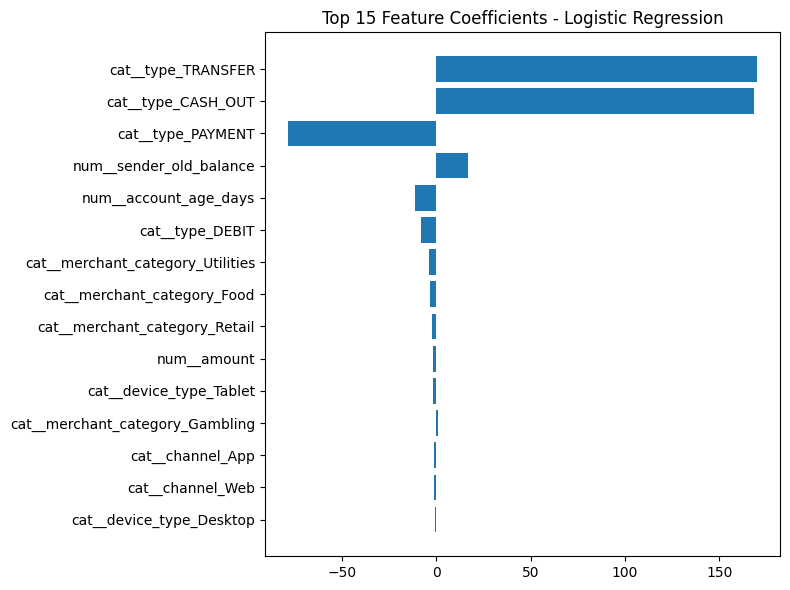

In [11]:
# Feature Importance via coefficients
import matplotlib.pyplot as plt
import numpy as np

feature_names = preprocessor.get_feature_names_out()
coefs = lgr_pipe.named_steps["model"].coef_[0]

top_idx = np.argsort(np.abs(coefs))[-15:]

plt.figure(figsize=(8, 6))
plt.barh(feature_names[top_idx], coefs[top_idx])
plt.title("Top 15 Feature Coefficients - Logistic Regression")
plt.tight_layout()
plt.show()

## 2. Random Forest

In [12]:
import optuna
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

X_sample, _, y_sample, _ = train_test_split(X_train, y_train, train_size=0.05,stratify=y_train, random_state=42)

def rf_objective(trial):
    params = {
        'n_estimators'      : trial.suggest_int('n_estimators', 50, 200), 
        'max_depth'         : trial.suggest_int('max_depth', 5, 20),
        'min_samples_split' : trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf'  : trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features'      : trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        'class_weight'      : 'balanced',
        'random_state'      : 42,
        'n_jobs'            : -1
    }
    
    rf_pipe_tune = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', RandomForestClassifier(**params))
    ])
    score = cross_val_score(rf_pipe_tune, X_sample, y_sample, cv=2,scoring='roc_auc', n_jobs=-1).mean()
    return score

study = optuna.create_study(direction='maximize')
study.optimize(rf_objective, n_trials=20)
print("Best Params:", study.best_params)
print("Best ROC-AUC:", round(study.best_value, 4))

Best Params: {'n_estimators': 200, 'max_depth': 20, 'min_samples_split': 7, 'min_samples_leaf': 5, 'max_features': 'sqrt'}
Best ROC-AUC: 0.9998


In [13]:
from sklearn.metrics import average_precision_score

best = study.best_params
best.update({'class_weight': 'balanced', 'random_state': 42, 'n_jobs': -1})

rf_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(**best))
])

rf_pipe.fit(X_train, y_train)
y_pred  = rf_pipe.predict(X_test)
y_proba = rf_pipe.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=['Legit', 'Fraud']))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba), 4))
print("PR-AUC :", round(average_precision_score(y_test, y_proba), 4))

              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00   1270881
       Fraud       0.78      0.95      0.85      1643

    accuracy                           1.00   1272524
   macro avg       0.89      0.97      0.93   1272524
weighted avg       1.00      1.00      1.00   1272524

ROC-AUC: 0.9999
PR-AUC : 0.9632


# 3. XGBoost (Final Model)

In [14]:
# Optuna tuning
import optuna
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split

optuna.logging.set_verbosity(optuna.logging.WARNING)

scale_pos_weight = (y_train == 0).sum() / y_train.sum()

X_sample, _, y_sample, _ = train_test_split(
    X_train, y_train, train_size=0.05,
    stratify=y_train, random_state=42
)

def xgb_objective(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 100, 300),
        'max_depth'        : trial.suggest_int('max_depth', 3, 8),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample'        : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight' : trial.suggest_int('min_child_weight', 1, 10),
        'scale_pos_weight' : scale_pos_weight,
        'random_state'     : 42,
        'n_jobs'           : -1
    }
    pipe = Pipeline([('pre', preprocessor), ('model', XGBClassifier(**params))])
    cv   = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    return cross_val_score(pipe, X_sample, y_sample, cv=cv, scoring='average_precision', n_jobs=-1).mean()

study = optuna.create_study(direction='maximize')
study.optimize(xgb_objective, n_trials=20, show_progress_bar=True)

print(f"Best PR-AUC : {study.best_value:.4f}")
print(f"Best Params : {study.best_params}")

  0%|          | 0/20 [00:00<?, ?it/s]

Best PR-AUC : 0.9632
Best Params : {'n_estimators': 216, 'max_depth': 6, 'learning_rate': 0.26166234403880984, 'subsample': 0.6850345600060211, 'colsample_bytree': 0.8569976432927087, 'min_child_weight': 1}


In [15]:
# Model + Evaluation 
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score

xgb_final = Pipeline([
    ('pre',   preprocessor),
    ('model', XGBClassifier(**study.best_params, scale_pos_weight=scale_pos_weight, random_state=42, n_jobs=-1))
])
xgb_final.fit(X_train, y_train)

y_pred  = xgb_final.predict(X_test) 
y_proba = xgb_final.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=['Legit', 'Fraud']))
print(f"ROC-AUC : {roc_auc_score(y_test, y_proba):.4f}")
print(f"PR-AUC  : {average_precision_score(y_test, y_proba):.4f}")

              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00   1270881
       Fraud       0.90      0.97      0.94      1643

    accuracy                           1.00   1272524
   macro avg       0.95      0.99      0.97   1272524
weighted avg       1.00      1.00      1.00   1272524

ROC-AUC : 1.0000
PR-AUC  : 0.9909


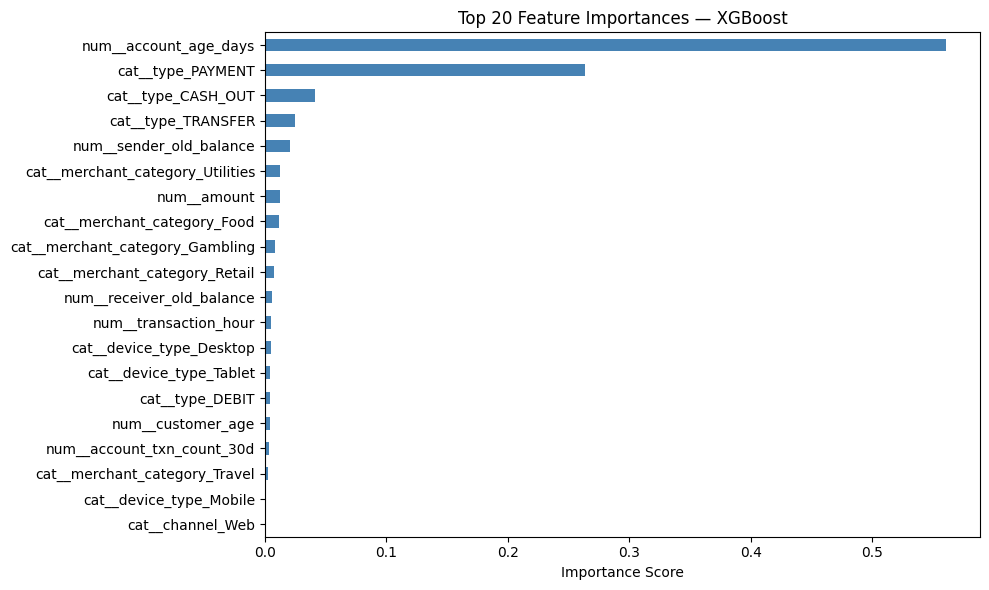

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

feat_names  = xgb_final.named_steps['pre'].get_feature_names_out()
importances = pd.Series(xgb_final.named_steps['model'].feature_importances_, index=feat_names)

top20 = importances.nlargest(20).sort_values()

plt.figure(figsize=(10, 6))
top20.plot(kind='barh', color='steelblue')
plt.title('Top 20 Feature Importances — XGBoost')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [18]:
import os
os.makedirs('../models', exist_ok=True)

import joblib
joblib.dump(xgb_final, '../models/xgb_fraud_model.pkl')
print("✓ Model saved → ../models/xgb_fraud_model.pkl")

✓ Model saved → ../models/xgb_fraud_model.pkl
